# MedTrust-Net Notebook B

**Goal:** Train baselines, run the full ablation study, and produce all benchmarking visualizations.




## 1. Setup (re-run this after any disconnect)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import torch, os, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: Tesla T4


In [ ]:
DRIVE_ROOT     = Path('/content/drive/MyDrive')
ZIP_PATH       = DRIVE_ROOT / 'CheXpert-v1.0-small.zip'
EXTRACT_DIR    = Path('/content/chexpert')
RESULTS_DIR    = DRIVE_ROOT / 'medtrust_results'
CHECKPOINT_DIR = RESULTS_DIR / 'checkpoints'
FIGURES_DIR    = RESULTS_DIR / 'figures'
METRICS_DIR    = RESULTS_DIR / 'metrics'

for d in [CHECKPOINT_DIR, FIGURES_DIR, METRICS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PATHOLOGIES = ['Atelectasis','Cardiomegaly','Consolidation','Edema','Pleural Effusion']
NUM_CLASSES = len(PATHOLOGIES)
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
SEED = 42

ABLATION_STAGE1_EPOCHS = 3
ABLATION_STAGE2_EPOCHS = 12
STAGE1_LR = 1e-3
STAGE2_LR = 1e-4
WEIGHT_DECAY = 1e-4
BETA_KL = 1e-3
BETA_CAL = 0.1

import random
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)


## 2. Dataset (fast re-extract, mirrors Notebook A)

In [ ]:
import zipfile

if not (EXTRACT_DIR / 'train.csv').exists() and not (EXTRACT_DIR / 'CheXpert-v1.0-small' / 'train.csv').exists():
    print("Extracting dataset (this takes ~5 min)...")
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print("Done.")
else:
    print("Dataset already extracted.")

DATA_ROOT = EXTRACT_DIR if (EXTRACT_DIR / 'train.csv').exists() else EXTRACT_DIR / 'CheXpert-v1.0-small'
print(f"Data root: {DATA_ROOT}")


Extracting dataset (this takes ~5 min)...
Done.
Data root: /content/chexpert


In [ ]:
train_csv = pd.read_csv(DATA_ROOT / 'train.csv')
valid_csv = pd.read_csv(DATA_ROOT / 'valid.csv')

train_csv = train_csv[train_csv['Frontal/Lateral'] == 'Frontal'].copy()
valid_csv = valid_csv[valid_csv['Frontal/Lateral'] == 'Frontal'].copy()

def apply_u_ones(df, cols):
    df = df.copy()
    for c in cols:
        df[c] = df[c].fillna(0).replace(-1, 1).astype(int)
    return df

train_csv = apply_u_ones(train_csv, PATHOLOGIES)
valid_csv = apply_u_ones(valid_csv, PATHOLOGIES)

# SAME seed as Notebook A -> same 20k
train_sampled = train_csv.sample(n=20000, random_state=SEED).reset_index(drop=True)
val_size = int(20000 * 0.10)
val_df   = train_sampled.iloc[:val_size].reset_index(drop=True)
train_df = train_sampled.iloc[val_size:].reset_index(drop=True)
test_df  = valid_csv.reset_index(drop=True)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

pos_weights = [(len(train_df) - train_df[p].sum()) / max(train_df[p].sum(), 1) for p in PATHOLOGIES]
pos_weights_tensor = torch.tensor(pos_weights, dtype=torch.float32)


Train: 18,000 | Val: 2,000 | Test: 202


In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CheXpertDataset(Dataset):
    def __init__(self, df, data_root, pathologies, transform=None):
        self.df = df.reset_index(drop=True)
        self.data_root = Path(data_root)
        self.path_prefix = self._detect_path_prefix()
        self.pathologies = pathologies
        self.transform = transform

    def _detect_path_prefix(self):
        sample_path = self.df.iloc[0]['Path']
        if (self.data_root / sample_path).exists():
            return self.data_root
        stripped = '/'.join(sample_path.split('/')[1:])
        if (self.data_root / stripped).exists():
            return 'STRIP'
        if (self.data_root.parent / sample_path).exists():
            return self.data_root.parent
        raise FileNotFoundError(f"Cannot locate: {sample_path}")

    def _resolve_path(self, csv_path):
        if self.path_prefix == 'STRIP':
            return self.data_root / '/'.join(csv_path.split('/')[1:])
        return self.path_prefix / csv_path

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self._resolve_path(row['Path'])).convert('RGB')
        if self.transform: img = self.transform(img)
        labels = torch.tensor([row[p] for p in self.pathologies], dtype=torch.float32)
        return img, labels

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = CheXpertDataset(train_df, DATA_ROOT, PATHOLOGIES, train_transform)
val_dataset   = CheXpertDataset(val_df,   DATA_ROOT, PATHOLOGIES, eval_transform)
test_dataset  = CheXpertDataset(test_df,  DATA_ROOT, PATHOLOGIES, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Loaders ready. Train batches: {len(train_loader)}")


Loaders ready. Train batches: 562


## 3. Model definitions

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights


class ConfidenceAwareAttentionBlock(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.in_channels = in_channels
        self.channel_pool_avg = nn.AdaptiveAvgPool2d(1)
        self.channel_pool_max = nn.AdaptiveMaxPool2d(1)
        hidden = max(in_channels // reduction, 8)
        self.channel_mlp_mu = nn.Sequential(
            nn.Linear(in_channels * 2, hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, in_channels))
        self.channel_mlp_logvar = nn.Sequential(
            nn.Linear(in_channels * 2, hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, in_channels))
        self.spatial_conv_mu = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.spatial_conv_logvar = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.last_spatial_mu = None
        self.last_spatial_logvar = None
        self.last_channel_mu = None
        self.last_channel_logvar = None

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu

    def forward(self, x):
        b, c, h, w = x.shape
        avg_c = self.channel_pool_avg(x).view(b, c)
        max_c = self.channel_pool_max(x).view(b, c)
        ch_in = torch.cat([avg_c, max_c], dim=1)
        ch_mu = self.channel_mlp_mu(ch_in)
        ch_logvar = torch.clamp(self.channel_mlp_logvar(ch_in), min=-10, max=2)
        ch_attn = torch.sigmoid(self.reparameterize(ch_mu, ch_logvar)).view(b, c, 1, 1)

        avg_s = torch.mean(x, dim=1, keepdim=True)
        max_s = torch.max(x, dim=1, keepdim=True)[0]
        sp_in = torch.cat([avg_s, max_s], dim=1)
        sp_mu = self.spatial_conv_mu(sp_in)
        sp_logvar = torch.clamp(self.spatial_conv_logvar(sp_in), min=-10, max=2)
        sp_attn = torch.sigmoid(self.reparameterize(sp_mu, sp_logvar))

        self.last_spatial_mu = sp_mu
        self.last_spatial_logvar = sp_logvar
        self.last_channel_mu = ch_mu
        self.last_channel_logvar = ch_logvar
        return x * ch_attn * sp_attn

    def kl_divergence(self):
        if self.last_spatial_mu is None:
            return torch.tensor(0.0, device=next(self.parameters()).device)
        kl_sp = -0.5 * torch.mean(1 + self.last_spatial_logvar
                                    - self.last_spatial_mu.pow(2)
                                    - self.last_spatial_logvar.exp())
        kl_ch = -0.5 * torch.mean(1 + self.last_channel_logvar
                                    - self.last_channel_mu.pow(2)
                                    - self.last_channel_logvar.exp())
        return kl_sp + kl_ch


class MedTrustNet(nn.Module):
    def __init__(self, num_classes=5, pretrained=True):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        bb = resnet50(weights=weights)
        self.stem = nn.Sequential(bb.conv1, bb.bn1, bb.relu, bb.maxpool)
        self.layer1 = bb.layer1; self.layer2 = bb.layer2
        self.layer3 = bb.layer3; self.layer4 = bb.layer4
        self.cab1 = ConfidenceAwareAttentionBlock(256)
        self.cab2 = ConfidenceAwareAttentionBlock(512)
        self.cab3 = ConfidenceAwareAttentionBlock(1024)
        self.cab4 = ConfidenceAwareAttentionBlock(2048)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(2048, num_classes)

    def forward(self, x, return_maps=False):
        x = self.stem(x)
        x = self.layer1(x); x = self.cab1(x)
        x = self.layer2(x); x = self.cab2(x)
        x = self.layer3(x); x = self.cab3(x)
        x = self.layer4(x); x = self.cab4(x)
        feat = self.avgpool(x).flatten(1)
        feat = self.dropout(feat)
        logits = self.classifier(feat)
        if return_maps:
            dam = torch.sigmoid(self.cab4.last_spatial_mu)
            crm = torch.exp(0.5 * self.cab4.last_spatial_logvar)
            return logits, dam, crm
        return logits

    def total_kl_divergence(self):
        return (self.cab1.kl_divergence() + self.cab2.kl_divergence()
              + self.cab3.kl_divergence() + self.cab4.kl_divergence())

    def freeze_backbone(self):
        for m in [self.stem, self.layer1, self.layer2, self.layer3, self.layer4]:
            for p in m.parameters(): p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.parameters(): p.requires_grad = True


class PlainResNet50(nn.Module):
    def __init__(self, num_classes=5, pretrained=True, dropout=0.3):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        bb = resnet50(weights=weights)
        self.stem = nn.Sequential(bb.conv1, bb.bn1, bb.relu, bb.maxpool)
        self.layer1 = bb.layer1; self.layer2 = bb.layer2
        self.layer3 = bb.layer3; self.layer4 = bb.layer4
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(2048, num_classes)

    def forward(self, x, return_features=False):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); feat_map = self.layer4(x)
        feat = self.avgpool(feat_map).flatten(1)
        feat = self.dropout(feat)
        logits = self.classifier(feat)
        if return_features:
            return logits, feat_map
        return logits

    def freeze_backbone(self):
        for m in [self.stem, self.layer1, self.layer2, self.layer3, self.layer4]:
            for p in m.parameters(): p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.parameters(): p.requires_grad = True


## 4. Loss functions and FULL evaluation metrics (AUROC, ECE, F1, precision, recall, specificity, accuracy)

In [ ]:
class SoftECELoss(nn.Module):
    def __init__(self, n_bins=15):
        super().__init__()
        self.n_bins = n_bins
        self.register_buffer('bin_centers', torch.linspace(0.0, 1.0, n_bins))
        self.bin_width = 1.0 / n_bins

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs_flat = probs.reshape(-1)
        targets_flat = targets.reshape(-1)
        sigma = self.bin_width
        diffs = probs_flat.unsqueeze(1) - self.bin_centers.unsqueeze(0)
        weights = torch.exp(-(diffs ** 2) / (2 * sigma ** 2))
        weights = weights / (weights.sum(dim=1, keepdim=True) + 1e-8)
        bin_conf = (weights * probs_flat.unsqueeze(1)).sum(dim=0)
        bin_acc  = (weights * targets_flat.unsqueeze(1)).sum(dim=0)
        bin_count = weights.sum(dim=0) + 1e-8
        avg_conf = bin_conf / bin_count
        avg_acc  = bin_acc / bin_count
        bin_weight = bin_count / bin_count.sum()
        return (bin_weight * torch.abs(avg_conf - avg_acc)).sum()


class HybridLoss(nn.Module):
    def __init__(self, pos_weights, beta_kl=1e-3, beta_cal=0.1, use_kl=True, use_cal=True):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
        self.cal = SoftECELoss(15)
        self.beta_kl = beta_kl if use_kl else 0.0
        self.beta_cal = beta_cal if use_cal else 0.0
        self.use_kl = use_kl

    def forward(self, logits, targets, model=None):
        l_bce = self.bce(logits, targets)
        l_kl = (model.total_kl_divergence() if (self.use_kl and model is not None
                                                 and hasattr(model, 'total_kl_divergence'))
                else torch.tensor(0.0, device=logits.device))
        l_cal = self.cal(logits, targets) if self.beta_cal > 0 else torch.tensor(0.0, device=logits.device)
        total = l_bce + self.beta_kl * l_kl + self.beta_cal * l_cal
        return total, {'bce': l_bce.item(), 'kl': float(l_kl), 'cal': float(l_cal), 'total': total.item()}


In [ ]:
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, accuracy_score, confusion_matrix)

def compute_full_metrics(probs, labels, pathologies, threshold=0.5):
    """
    Compute a full set of classification metrics.
    probs: (N, C) float in [0,1]
    labels: (N, C) int in {0,1}
    Returns dict with per-class and macro-averaged metrics.
    """
    per_class = {}
    macro = {'auroc': [], 'ece': [], 'f1': [], 'precision': [], 'recall': [],
             'specificity': [], 'accuracy': []}

    preds = (probs >= threshold).astype(int)

    def hard_ece(p, y, n_bins=15):
        edges = np.linspace(0, 1, n_bins + 1)
        e = 0.0
        for j in range(n_bins):
            mask = (p > edges[j]) & (p <= edges[j+1])
            if mask.sum() == 0: continue
            e += (mask.sum() / len(p)) * abs(p[mask].mean() - y[mask].mean())
        return float(e)

    for i, path in enumerate(pathologies):
        y = labels[:, i]
        p = probs[:, i]
        pred = preds[:, i]

        if y.sum() == 0 or y.sum() == len(y):
            per_class[path] = {'auroc': float('nan'), 'ece': float('nan'),
                               'f1': float('nan'), 'precision': float('nan'),
                               'recall': float('nan'), 'specificity': float('nan'),
                               'accuracy': float('nan')}
            continue

        auroc = float(roc_auc_score(y, p))
        ece = hard_ece(p, y)
        f1 = float(f1_score(y, pred, zero_division=0))
        prec = float(precision_score(y, pred, zero_division=0))
        rec = float(recall_score(y, pred, zero_division=0))
        acc = float(accuracy_score(y, pred))
        # Specificity = TN / (TN + FP)
        tn = int(((pred == 0) & (y == 0)).sum())
        fp = int(((pred == 1) & (y == 0)).sum())
        spec = float(tn / (tn + fp)) if (tn + fp) > 0 else float('nan')

        per_class[path] = {
            'auroc': auroc, 'ece': ece, 'f1': f1, 'precision': prec,
            'recall': rec, 'specificity': spec, 'accuracy': acc,
        }
        for k, v in [('auroc', auroc), ('ece', ece), ('f1', f1),
                     ('precision', prec), ('recall', rec),
                     ('specificity', spec), ('accuracy', acc)]:
            if not np.isnan(v):
                macro[k].append(v)

    macro_out = {f'macro_{k}': float(np.mean(v)) if v else float('nan')
                 for k, v in macro.items()}
    return {'per_class': per_class, **macro_out}


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []
    for imgs, lbls in loader:
        imgs = imgs.to(device, non_blocking=True)
        logits = model(imgs)
        all_logits.append(logits.cpu().numpy())
        all_labels.append(lbls.numpy())
    logits = np.concatenate(all_logits)
    labels = np.concatenate(all_labels)
    probs = 1 / (1 + np.exp(-logits))
    metrics = compute_full_metrics(probs, labels, PATHOLOGIES)
    metrics['_probs'] = probs
    metrics['_labels'] = labels
    return metrics


def strip_arrays(m):
    return {k: v for k, v in m.items() if not k.startswith('_')}

def print_metrics(name, m):
    print(f"\n=== {name} ===")
    print(f"Macro: AUROC={m['macro_auroc']:.4f} ECE={m['macro_ece']:.4f} "
          f"F1={m['macro_f1']:.4f} Prec={m['macro_precision']:.4f} "
          f"Rec={m['macro_recall']:.4f} Spec={m['macro_specificity']:.4f}")
    print("Per-class:")
    for path, pc in m['per_class'].items():
        print(f"  {path:20s}: AUROC={pc['auroc']:.3f} ECE={pc['ece']:.3f} "
              f"F1={pc['f1']:.3f} P={pc['precision']:.3f} R={pc['recall']:.3f}")


## 5. Generic training loop

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

def train_model(model, criterion, train_loader, val_loader, device,
                stage1_epochs, stage2_epochs, stage1_lr, stage2_lr, weight_decay,
                tag='model'):
    history = {'train': [], 'val': []}

    print(f"\n[{tag}] STAGE 1: frozen backbone")
    model.freeze_backbone()
    opt = AdamW([p for p in model.parameters() if p.requires_grad],
                lr=stage1_lr, weight_decay=weight_decay)
    for epoch in range(1, stage1_epochs + 1):
        model.train()
        t0 = time.time()
        running = {'total': 0, 'n': 0}
        for imgs, lbls in train_loader:
            imgs = imgs.to(device, non_blocking=True)
            lbls = lbls.to(device, non_blocking=True)
            opt.zero_grad()
            logits = model(imgs)
            loss, parts = criterion(logits, lbls, model)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            opt.step()
            running['total'] += parts['total'] * imgs.size(0)
            running['n'] += imgs.size(0)
        avg_loss = running['total'] / running['n']
        val_m = evaluate(model, val_loader, device)
        print(f"  [{tag}] s1-ep{epoch}: loss={avg_loss:.4f} | "
              f"val AUROC={val_m['macro_auroc']:.4f} ECE={val_m['macro_ece']:.4f} "
              f"({time.time()-t0:.0f}s)")
        history['train'].append({'epoch': epoch, 'stage': 1, 'loss': avg_loss})
        history['val'].append({'epoch': epoch, 'stage': 1,
                               'macro_auroc': val_m['macro_auroc'],
                               'macro_ece': val_m['macro_ece']})

    print(f"\n[{tag}] STAGE 2: full fine-tuning")
    model.unfreeze_backbone()
    opt = AdamW(model.parameters(), lr=stage2_lr, weight_decay=weight_decay)
    sched = CosineAnnealingLR(opt, T_max=stage2_epochs, eta_min=1e-6)

    best_score = -float('inf')
    best_state = None

    for epoch in range(1, stage2_epochs + 1):
        model.train()
        t0 = time.time()
        running = {'total': 0, 'n': 0}
        for imgs, lbls in train_loader:
            imgs = imgs.to(device, non_blocking=True)
            lbls = lbls.to(device, non_blocking=True)
            opt.zero_grad()
            logits = model(imgs)
            loss, parts = criterion(logits, lbls, model)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            opt.step()
            running['total'] += parts['total'] * imgs.size(0)
            running['n'] += imgs.size(0)
        sched.step()
        avg_loss = running['total'] / running['n']
        val_m = evaluate(model, val_loader, device)
        print(f"  [{tag}] s2-ep{epoch}: loss={avg_loss:.4f} | "
              f"val AUROC={val_m['macro_auroc']:.4f} ECE={val_m['macro_ece']:.4f} "
              f"({time.time()-t0:.0f}s)")
        history['train'].append({'epoch': stage1_epochs + epoch, 'stage': 2, 'loss': avg_loss})
        history['val'].append({'epoch': stage1_epochs + epoch, 'stage': 2,
                               'macro_auroc': val_m['macro_auroc'],
                               'macro_ece': val_m['macro_ece']})

        score = val_m['macro_auroc'] - val_m['macro_ece']
        if score > best_score:
            best_score = score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"[{tag}] Loaded best epoch (score={best_score:.4f})")
    return model, history


## 6. Resume-safe training helper

Each variant checks for existing `{tag}_metrics.json` AND `{tag}.pt` on disk.
- If both exist: skip training, load weights + metrics from disk.
- If neither exists: train, then save both.
- If only checkpoint exists: skip training, load weights, re-run evaluation, save metrics.

**This makes the notebook fully re-runnable after Colab disconnects.**


In [ ]:
def train_or_load_variant(tag, model_cls, loss_kwargs, train_loader, val_loader,
                           test_loader, device, stage1_epochs=ABLATION_STAGE1_EPOCHS,
                           stage2_epochs=ABLATION_STAGE2_EPOCHS):
    """Train a variant, or load it from disk if already trained."""
    metrics_path = METRICS_DIR / f'{tag}_metrics.json'
    ckpt_path = CHECKPOINT_DIR / f'{tag}.pt'

    model = model_cls(num_classes=NUM_CLASSES, pretrained=True).to(device)

    if metrics_path.exists() and ckpt_path.exists():
        print(f"[{tag}] CACHED -> loading from disk")
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        with open(metrics_path) as f:
            cached = json.load(f)
        # Need to re-run evaluation to get probs/labels arrays for figures
        test_m = evaluate(model, test_loader, device)
        return model, test_m

    if ckpt_path.exists() and not metrics_path.exists():
        print(f"[{tag}] CHECKPOINT FOUND -> skipping training, re-running eval")
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        test_m = evaluate(model, test_loader, device)
        with open(metrics_path, 'w') as f:
            json.dump(strip_arrays(test_m), f, indent=2, default=str)
        print(f"[{tag}] Saved metrics")
        return model, test_m

    # Full training
    print(f"[{tag}] TRAINING FROM SCRATCH")
    criterion = HybridLoss(pos_weights_tensor.to(device), **loss_kwargs)
    model, hist = train_model(model, criterion, train_loader, val_loader, device,
                              stage1_epochs, stage2_epochs, STAGE1_LR, STAGE2_LR,
                              WEIGHT_DECAY, tag=tag)
    # Save checkpoint
    torch.save(model.state_dict(), ckpt_path)
    print(f"[{tag}] Saved checkpoint -> {ckpt_path}")

    # Evaluate on test set with full metrics
    test_m = evaluate(model, test_loader, device)
    print_metrics(tag, test_m)

    # Save metrics immediately
    with open(metrics_path, 'w') as f:
        json.dump(strip_arrays(test_m), f, indent=2, default=str)
    print(f"[{tag}] Saved metrics -> {metrics_path}")

    return model, test_m


## 7. Train / load all variants (RESUME-SAFE)

**If Colab disconnects, just re-run this cell.** Each variant checks disk first.

**Order of variants (trains first, cached second):**
1. `resnet50_baseline` — plain ResNet-50 ← you already have this, will be cached
2. `resnet50_cal` — + calibration loss
3. `medtrust_cab_only` — + CAB but no cal loss
4. `medtrust_full` — loaded from Notebook A's `best.pt`


In [ ]:
# --- Variant 1: ResNet-50 baseline ---
m_baseline, metrics_baseline = train_or_load_variant(
    'resnet50_baseline', PlainResNet50,
    {'use_kl': False, 'use_cal': False},
    train_loader, val_loader, test_loader, device
)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


[resnet50_baseline] CACHED -> loading from disk


In [ ]:
# --- Variant 2: ResNet-50 + calibration loss ---
m_cal, metrics_cal = train_or_load_variant(
    'resnet50_cal', PlainResNet50,
    {'use_kl': False, 'use_cal': True, 'beta_cal': BETA_CAL},
    train_loader, val_loader, test_loader, device
)


[resnet50_cal] CACHED -> loading from disk


In [ ]:
# --- Variant 3: MedTrust-Net CAB-only (no calibration loss) ---
m_cab, metrics_cab = train_or_load_variant(
    'medtrust_cab_only', MedTrustNet,
    {'use_kl': True, 'use_cal': False, 'beta_kl': BETA_KL},
    train_loader, val_loader, test_loader, device
)


[medtrust_cab_only] CACHED -> loading from disk


In [ ]:
# --- Variant 4: Full MedTrust-Net (load from Notebook A) ---
tag = 'medtrust_full'
metrics_path = METRICS_DIR / f'{tag}_metrics.json'
m_full = MedTrustNet(num_classes=NUM_CLASSES, pretrained=False).to(device)
ckpt = torch.load(CHECKPOINT_DIR / 'best.pt', map_location=device, weights_only=False)
m_full.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded MedTrust-Net (full) from epoch {ckpt['epoch']}")
metrics_full = evaluate(m_full, test_loader, device)
print_metrics(tag, metrics_full)
with open(metrics_path, 'w') as f:
    json.dump(strip_arrays(metrics_full), f, indent=2, default=str)


Loaded MedTrust-Net (full) from epoch 22

=== medtrust_full ===
Macro: AUROC=0.8702 ECE=0.1136 F1=0.6540 Prec=0.6546 Rec=0.7023 Spec=0.8556
Per-class:
  Atelectasis         : AUROC=0.822 ECE=0.082 F1=0.683 P=0.629 R=0.747
  Cardiomegaly        : AUROC=0.810 ECE=0.122 F1=0.535 P=0.771 R=0.409
  Consolidation       : AUROC=0.889 ECE=0.197 F1=0.593 P=0.458 R=0.844
  Edema               : AUROC=0.913 ECE=0.109 F1=0.703 P=0.653 R=0.762
  Pleural Effusion    : AUROC=0.917 ECE=0.058 F1=0.756 P=0.762 R=0.750


## 8. MC Dropout (reuses resnet50_baseline weights)

In [ ]:
def enable_dropout(model):
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

@torch.no_grad()
def mc_dropout_evaluate(model, loader, device, n_samples=20):
    model.eval()
    enable_dropout(model)
    all_probs_mean, all_labels = [], []
    for imgs, lbls in loader:
        imgs = imgs.to(device)
        sample_probs = [torch.sigmoid(model(imgs)).cpu().numpy() for _ in range(n_samples)]
        all_probs_mean.append(np.mean(sample_probs, axis=0))
        all_labels.append(lbls.numpy())
    probs = np.concatenate(all_probs_mean)
    labels = np.concatenate(all_labels)
    m = compute_full_metrics(probs, labels, PATHOLOGIES)
    m['_probs'] = probs
    m['_labels'] = labels
    return m

mc_metrics_path = METRICS_DIR / 'mc_dropout_metrics.json'
if mc_metrics_path.exists():
    print("[mc_dropout] CACHED -> re-running eval (fast)")
metrics_mcd = mc_dropout_evaluate(m_baseline, test_loader, device, n_samples=20)
print_metrics('mc_dropout', metrics_mcd)
with open(mc_metrics_path, 'w') as f:
    json.dump(strip_arrays(metrics_mcd), f, indent=2, default=str)


[mc_dropout] CACHED -> re-running eval (fast)

=== mc_dropout ===
Macro: AUROC=0.8676 ECE=0.0990 F1=0.6216 Prec=0.6445 Rec=0.6302 Spec=0.8699
Per-class:
  Atelectasis         : AUROC=0.819 ECE=0.061 F1=0.630 P=0.648 R=0.613
  Cardiomegaly        : AUROC=0.814 ECE=0.081 F1=0.519 P=0.711 R=0.409
  Consolidation       : AUROC=0.863 ECE=0.163 F1=0.541 P=0.434 R=0.719
  Edema               : AUROC=0.925 ECE=0.116 F1=0.713 P=0.689 R=0.738
  Pleural Effusion    : AUROC=0.916 ECE=0.073 F1=0.705 P=0.741 R=0.672


## 9. Deep Ensemble (2 extra seeds)

In [ ]:
# Train 2 additional ensemble members (if not cached), then combine with baseline
ensemble_members = [m_baseline]

for seed_idx, seed in enumerate([123, 456], start=2):
    tag = f'ensemble_member_{seed_idx}'
    ckpt_path = CHECKPOINT_DIR / f'{tag}.pt'
    if ckpt_path.exists():
        print(f"[{tag}] CACHED")
        m_e = PlainResNet50(num_classes=NUM_CLASSES, pretrained=True).to(device)
        m_e.load_state_dict(torch.load(ckpt_path, map_location=device))
    else:
        print(f"\n=== Training ensemble member {seed_idx} ===")
        torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
        m_e = PlainResNet50(num_classes=NUM_CLASSES, pretrained=True).to(device)
        loss_e = HybridLoss(pos_weights_tensor.to(device), use_kl=False, use_cal=False)
        m_e, _ = train_model(m_e, loss_e, train_loader, val_loader, device,
                             stage1_epochs=2, stage2_epochs=8,
                             stage1_lr=STAGE1_LR, stage2_lr=STAGE2_LR,
                             weight_decay=WEIGHT_DECAY, tag=tag)
        torch.save(m_e.state_dict(), ckpt_path)
    ensemble_members.append(m_e)

@torch.no_grad()
def ensemble_evaluate(models, loader, device):
    for m in models: m.eval()
    all_probs, all_labels = [], []
    for imgs, lbls in loader:
        imgs = imgs.to(device)
        probs_list = [torch.sigmoid(m(imgs)).cpu().numpy() for m in models]
        all_probs.append(np.mean(probs_list, axis=0))
        all_labels.append(lbls.numpy())
    probs = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    m = compute_full_metrics(probs, labels, PATHOLOGIES)
    m['_probs'] = probs
    m['_labels'] = labels
    return m

metrics_ens = ensemble_evaluate(ensemble_members, test_loader, device)
print_metrics('deep_ensemble', metrics_ens)
with open(METRICS_DIR / 'deep_ensemble_metrics.json', 'w') as f:
    json.dump(strip_arrays(metrics_ens), f, indent=2, default=str)


[ensemble_member_2] CACHED

=== Training ensemble member 3 ===

[ensemble_member_3] STAGE 1: frozen backbone
  [ensemble_member_3] s1-ep1: loss=0.9496 | val AUROC=0.6643 ECE=0.2065 (141s)
  [ensemble_member_3] s1-ep2: loss=0.9305 | val AUROC=0.6719 ECE=0.2260 (123s)

[ensemble_member_3] STAGE 2: full fine-tuning
  [ensemble_member_3] s2-ep1: loss=0.8777 | val AUROC=0.7465 ECE=0.1888 (190s)
  [ensemble_member_3] s2-ep2: loss=0.8280 | val AUROC=0.7551 ECE=0.1822 (194s)
  [ensemble_member_3] s2-ep3: loss=0.8025 | val AUROC=0.7618 ECE=0.1770 (195s)
  [ensemble_member_3] s2-ep4: loss=0.7819 | val AUROC=0.7678 ECE=0.1600 (194s)
  [ensemble_member_3] s2-ep5: loss=0.7613 | val AUROC=0.7675 ECE=0.1224 (194s)
  [ensemble_member_3] s2-ep6: loss=0.7354 | val AUROC=0.7643 ECE=0.1185 (194s)
  [ensemble_member_3] s2-ep7: loss=0.7112 | val AUROC=0.7639 ECE=0.1195 (193s)
  [ensemble_member_3] s2-ep8: loss=0.6949 | val AUROC=0.7629 ECE=0.1175 (193s)
[ensemble_member_3] Loaded best epoch (score=0.6457)



## 10. Inference time and model size

In [ ]:
def measure_inference_time(model, device, n_warmup=10, n_iters=50):
    model.eval()
    dummy = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
    with torch.no_grad():
        for _ in range(n_warmup): _ = model(dummy)
        if device.type == 'cuda': torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(n_iters): _ = model(dummy)
        if device.type == 'cuda': torch.cuda.synchronize()
    return 1000 * (time.time() - t0) / n_iters

def model_size_mb(model):
    return sum(p.numel() for p in model.parameters()) * 4 / 1e6

inference_results = {}
for name, m in [('resnet50_baseline', m_baseline),
                ('resnet50_cal', m_cal),
                ('medtrust_cab_only', m_cab),
                ('medtrust_full', m_full)]:
    t_ms = measure_inference_time(m, device)
    sz = model_size_mb(m)
    inference_results[name] = {'inference_ms': t_ms, 'size_mb': sz}

inference_results['mc_dropout'] = {
    'inference_ms': inference_results['resnet50_baseline']['inference_ms'] * 20,
    'size_mb': inference_results['resnet50_baseline']['size_mb']
}
inference_results['deep_ensemble'] = {
    'inference_ms': inference_results['resnet50_baseline']['inference_ms'] * 3,
    'size_mb': inference_results['resnet50_baseline']['size_mb'] * 3
}
for name, r in inference_results.items():
    print(f"  {name:25s}: {r['inference_ms']:6.2f} ms | {r['size_mb']:6.1f} MB")


  resnet50_baseline        :   6.10 ms |   94.1 MB
  resnet50_cal             :   5.72 ms |   94.1 MB
  medtrust_cab_only        :   8.70 ms |  102.5 MB
  medtrust_full            :   8.61 ms |  102.5 MB
  mc_dropout               : 122.01 ms |   94.1 MB
  deep_ensemble            :  18.30 ms |  282.2 MB


## 11. Aggregate all results

In [ ]:
all_results = {
    'resnet50_baseline':  {**strip_arrays(metrics_baseline), **inference_results['resnet50_baseline']},
    'resnet50_cal':       {**strip_arrays(metrics_cal),      **inference_results['resnet50_cal']},
    'medtrust_cab_only':  {**strip_arrays(metrics_cab),      **inference_results['medtrust_cab_only']},
    'medtrust_full':      {**strip_arrays(metrics_full),     **inference_results['medtrust_full']},
    'mc_dropout':         {**strip_arrays(metrics_mcd),      **inference_results['mc_dropout']},
    'deep_ensemble':      {**strip_arrays(metrics_ens),      **inference_results['deep_ensemble']},
}

with open(METRICS_DIR / 'all_models_comparison.json', 'w') as f:
    json.dump(all_results, f, indent=2, default=str)

# Summary table with full metrics
print("\n" + "=" * 110)
print(f"{'Model':22s} {'AUROC':>8s} {'ECE':>8s} {'F1':>8s} {'Prec':>8s} {'Recall':>8s} {'Spec':>8s} {'Acc':>8s} {'ms':>8s}")
print("=" * 110)
for name, r in all_results.items():
    print(f"{name:22s} {r['macro_auroc']:>8.4f} {r['macro_ece']:>8.4f} "
          f"{r['macro_f1']:>8.4f} {r['macro_precision']:>8.4f} "
          f"{r['macro_recall']:>8.4f} {r['macro_specificity']:>8.4f} "
          f"{r['macro_accuracy']:>8.4f} {r['inference_ms']:>8.1f}")



Model                     AUROC      ECE       F1     Prec   Recall     Spec      Acc       ms
resnet50_baseline        0.8682   0.0977   0.6324   0.6568   0.6391   0.8750   0.8040      6.1
resnet50_cal             0.8591   0.1146   0.5849   0.6366   0.5876   0.8748   0.7911      5.7
medtrust_cab_only        0.8775   0.1143   0.6446   0.6328   0.7089   0.8407   0.7990      8.7
medtrust_full            0.8702   0.1136   0.6540   0.6546   0.7023   0.8556   0.8079      8.6
mc_dropout               0.8676   0.0990   0.6216   0.6445   0.6302   0.8699   0.7980    122.0
deep_ensemble            0.8718   0.1132   0.6391   0.6751   0.6703   0.8662   0.8050     18.3


## 12. Visualizations (all saved to figures/)

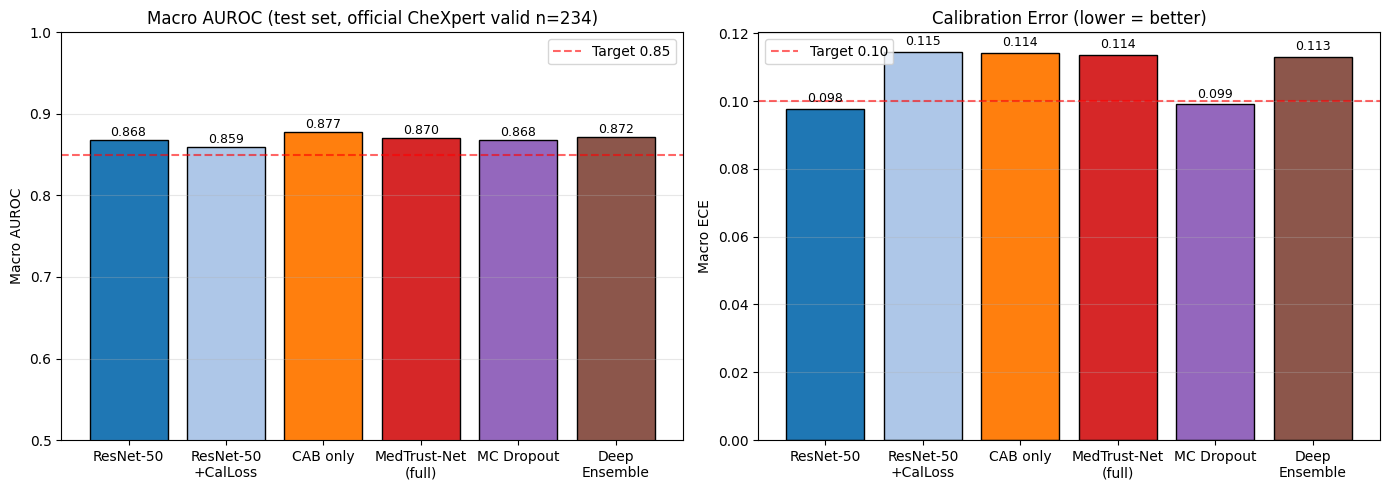

In [ ]:
model_names = list(all_results.keys())
display_names = {
    'resnet50_baseline': 'ResNet-50',
    'resnet50_cal': 'ResNet-50\n+CalLoss',
    'medtrust_cab_only': 'CAB only',
    'medtrust_full': 'MedTrust-Net\n(full)',
    'mc_dropout': 'MC Dropout',
    'deep_ensemble': 'Deep\nEnsemble',
}
labels_x = [display_names[n] for n in model_names]
colors = ['#1f77b4','#aec7e8','#ff7f0e','#d62728','#9467bd','#8c564b']

# --- Figure 1: AUROC + ECE ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
aurocs = [all_results[n]['macro_auroc'] for n in model_names]
eces   = [all_results[n]['macro_ece']   for n in model_names]

bars = axes[0].bar(labels_x, aurocs, color=colors, edgecolor='black')
axes[0].axhline(0.85, color='red', ls='--', alpha=0.6, label='Target 0.85')
axes[0].set_ylabel('Macro AUROC')
axes[0].set_title('Macro AUROC (test set, official CheXpert valid n=234)')
axes[0].set_ylim(0.5, 1.0); axes[0].grid(axis='y', alpha=0.3); axes[0].legend()
for b, v in zip(bars, aurocs):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.3f}', ha='center', fontsize=9)

bars = axes[1].bar(labels_x, eces, color=colors, edgecolor='black')
axes[1].axhline(0.10, color='red', ls='--', alpha=0.6, label='Target 0.10')
axes[1].set_ylabel('Macro ECE')
axes[1].set_title('Calibration Error (lower = better)')
axes[1].grid(axis='y', alpha=0.3); axes[1].legend()
for b, v in zip(bars, eces):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.002, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'auroc_ece_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


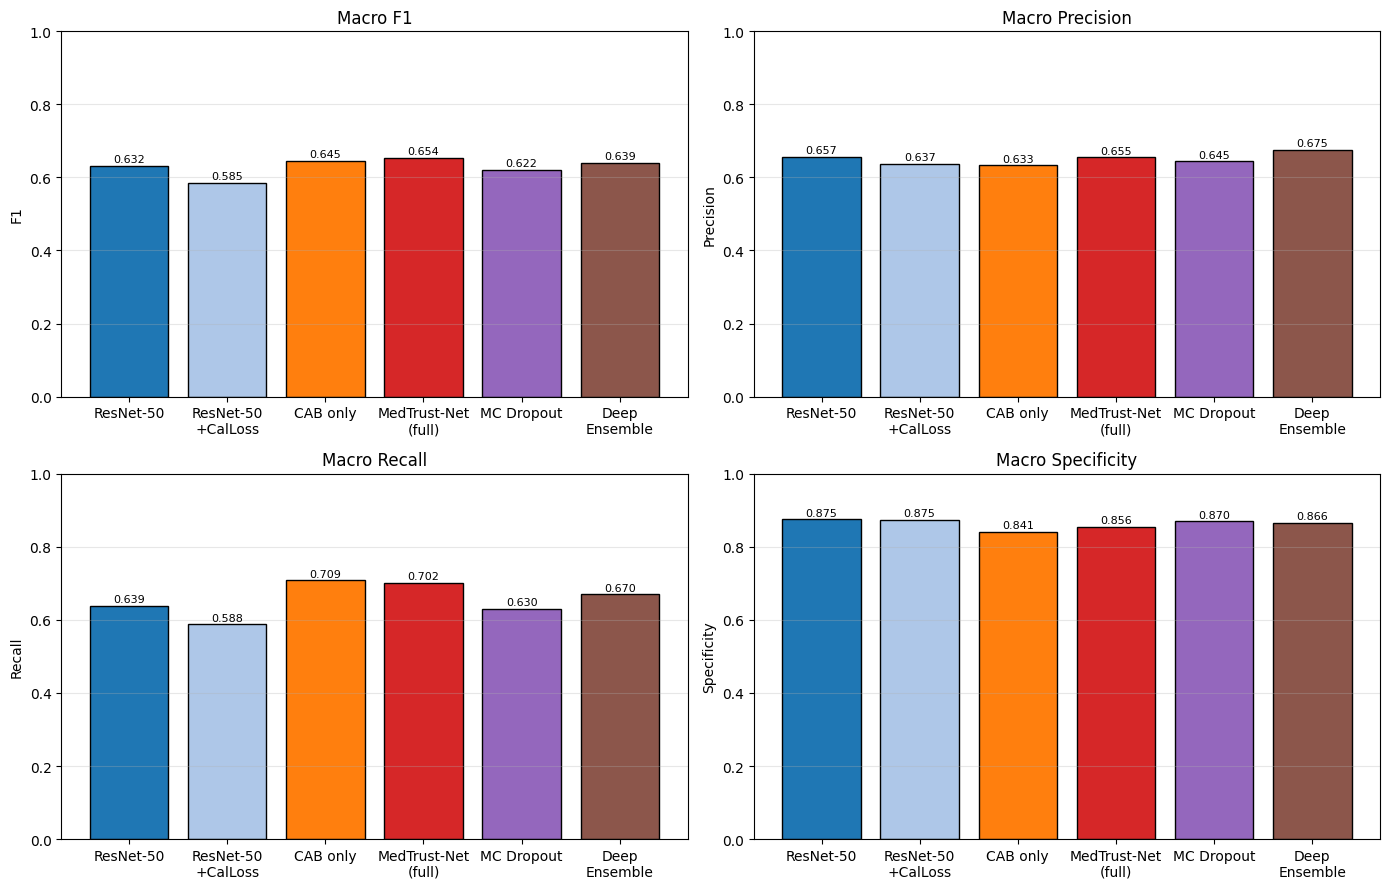

In [ ]:
# --- Figure 2: Full metrics comparison (F1, precision, recall) ---
metrics_to_plot = ['macro_f1', 'macro_precision', 'macro_recall', 'macro_specificity']
metric_labels = ['F1', 'Precision', 'Recall', 'Specificity']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, key, label in zip(axes.flat, metrics_to_plot, metric_labels):
    vals = [all_results[n][key] for n in model_names]
    bars = ax.bar(labels_x, vals, color=colors, edgecolor='black')
    ax.set_ylabel(label)
    ax.set_title(f'Macro {label}')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'full_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


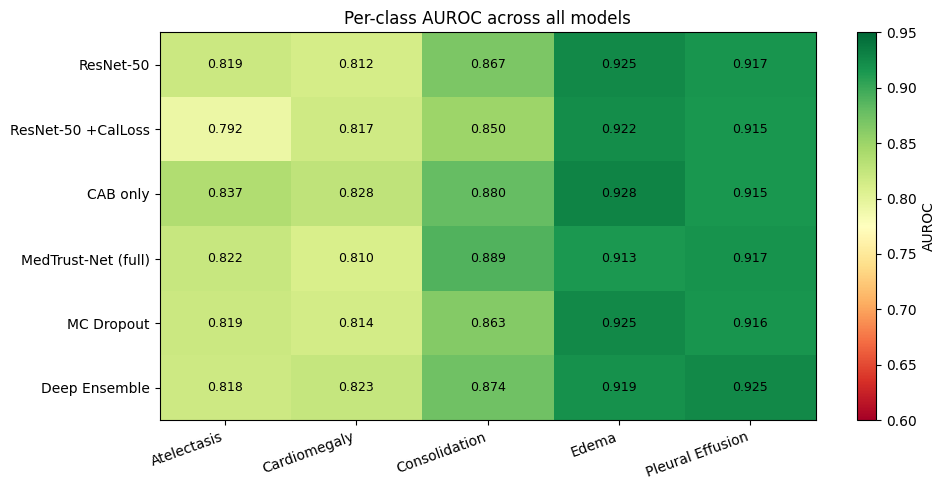

In [ ]:
# --- Figure 3: Per-class AUROC heatmap ---
matrix = np.array([[all_results[n]['per_class'][p]['auroc'] for p in PATHOLOGIES]
                   for n in model_names])

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(matrix, cmap='RdYlGn', vmin=0.6, vmax=0.95, aspect='auto')
ax.set_xticks(range(len(PATHOLOGIES)))
ax.set_xticklabels(PATHOLOGIES, rotation=20, ha='right')
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels([display_names[n].replace('\n',' ') for n in model_names])
for i in range(len(model_names)):
    for j in range(len(PATHOLOGIES)):
        ax.text(j, i, f'{matrix[i,j]:.3f}', ha='center', va='center',
                color='black', fontsize=9)
plt.colorbar(im, ax=ax, label='AUROC')
ax.set_title('Per-class AUROC across all models')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'per_class_auroc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


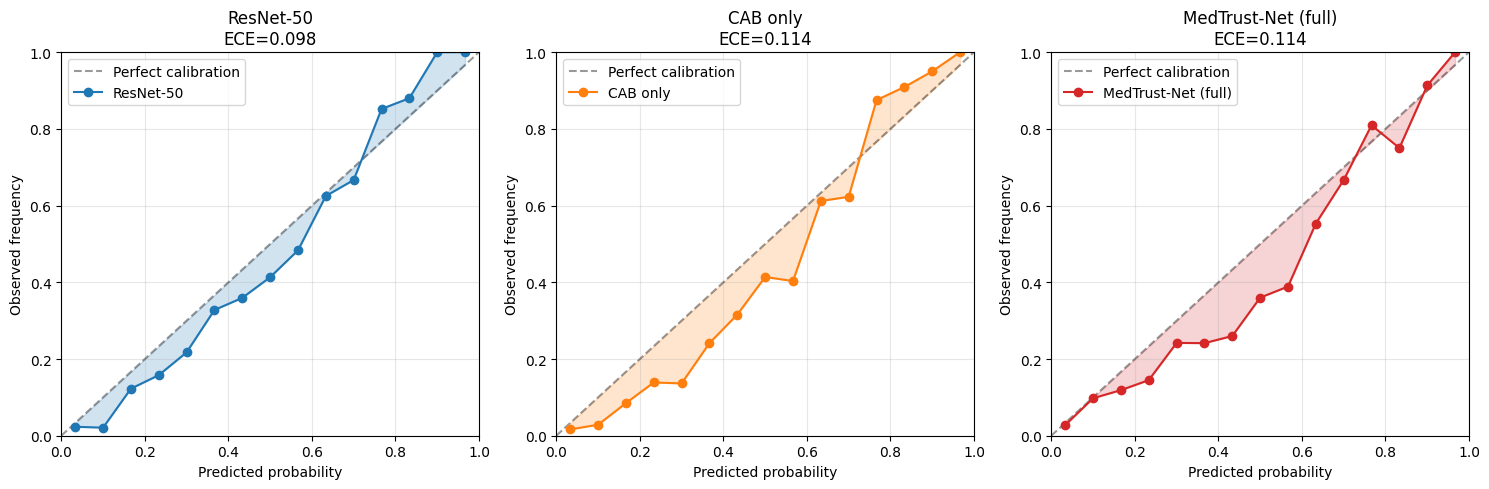

In [ ]:
# --- Figure 4: Reliability diagrams ---
def reliability_diagram(probs, labels, n_bins=15):
    edges = np.linspace(0, 1, n_bins + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    confs, accs = [], []
    for j in range(n_bins):
        mask = (probs > edges[j]) & (probs <= edges[j+1])
        if mask.sum() < 5:
            confs.append(np.nan); accs.append(np.nan)
        else:
            confs.append(probs[mask].mean()); accs.append(labels[mask].mean())
    return centers, np.array(confs), np.array(accs)

models_for_reliability = [
    ('resnet50_baseline', metrics_baseline, '#1f77b4'),
    ('medtrust_cab_only', metrics_cab,      '#ff7f0e'),
    ('medtrust_full',     metrics_full,     '#d62728'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, m, color) in zip(axes, models_for_reliability):
    probs_flat = m['_probs'].reshape(-1)
    labels_flat = m['_labels'].reshape(-1)
    centers, confs, accs = reliability_diagram(probs_flat, labels_flat)
    ax.plot([0,1],[0,1],'k--',alpha=0.4,label='Perfect calibration')
    ax.plot(centers, accs, 'o-', color=color, label=display_names[name].replace('\n',' '))
    ax.fill_between(centers, accs, centers, alpha=0.2, color=color)
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Observed frequency')
    ax.set_title(f"{display_names[name].replace(chr(10),' ')}\nECE={m['macro_ece']:.3f}")
    ax.legend(); ax.grid(alpha=0.3)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'reliability_diagrams.png', dpi=150, bbox_inches='tight')
plt.show()


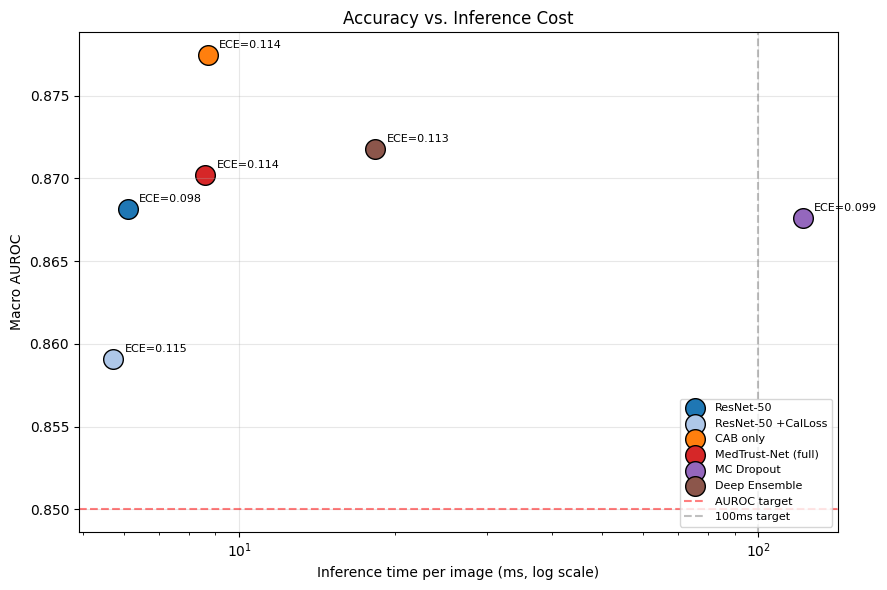

In [ ]:
# --- Figure 5: Inference time vs accuracy ---
fig, ax = plt.subplots(figsize=(9, 6))
for name, color in zip(model_names, colors):
    r = all_results[name]
    ax.scatter(r['inference_ms'], r['macro_auroc'], s=200, c=color,
               edgecolors='black', label=display_names[name].replace('\n',' '))
    ax.annotate(f"ECE={r['macro_ece']:.3f}",
                (r['inference_ms'], r['macro_auroc']),
                xytext=(8, 5), textcoords='offset points', fontsize=8)
ax.axhline(0.85, color='red', ls='--', alpha=0.5, label='AUROC target')
ax.axvline(100, color='gray', ls='--', alpha=0.5, label='100ms target')
ax.set_xscale('log')
ax.set_xlabel('Inference time per image (ms, log scale)')
ax.set_ylabel('Macro AUROC')
ax.set_title('Accuracy vs. Inference Cost')
ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'accuracy_vs_inference.png', dpi=150, bbox_inches='tight')
plt.show()


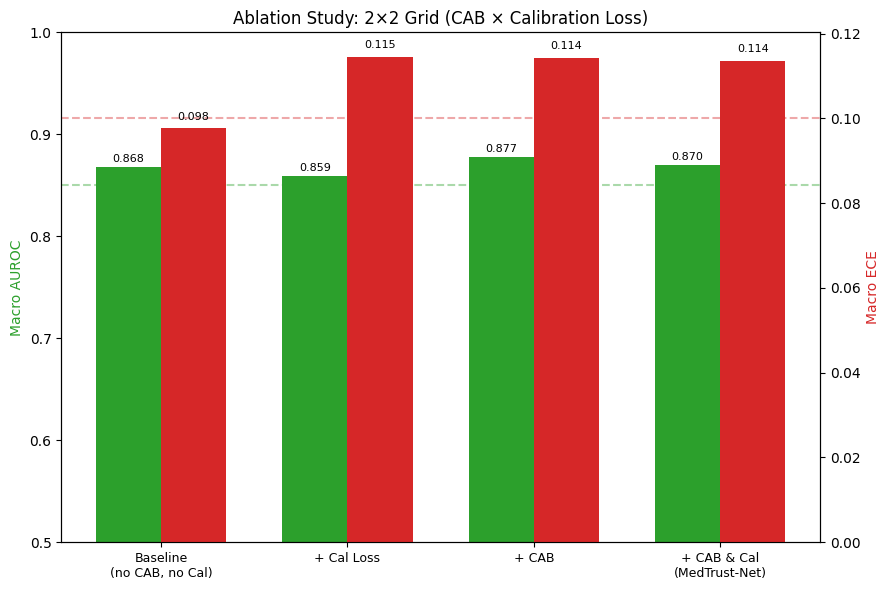

In [ ]:
# --- Figure 6: Ablation 2x2 grid ---
fig, ax = plt.subplots(figsize=(9, 6))
ablation_models = ['resnet50_baseline','resnet50_cal','medtrust_cab_only','medtrust_full']
ab_aurocs = [all_results[n]['macro_auroc'] for n in ablation_models]
ab_eces   = [all_results[n]['macro_ece'] for n in ablation_models]
ab_labels = ['Baseline\n(no CAB, no Cal)','+ Cal Loss','+ CAB','+ CAB & Cal\n(MedTrust-Net)']

x = np.arange(len(ablation_models))
w = 0.35
ax.bar(x - w/2, ab_aurocs, w, label='Macro AUROC', color='#2ca02c')
ax2 = ax.twinx()
ax2.bar(x + w/2, ab_eces, w, label='Macro ECE', color='#d62728')
ax.set_xticks(x); ax.set_xticklabels(ab_labels, fontsize=9)
ax.set_ylabel('Macro AUROC', color='#2ca02c')
ax2.set_ylabel('Macro ECE', color='#d62728')
ax.set_title('Ablation Study: 2×2 Grid (CAB × Calibration Loss)')
ax.axhline(0.85, color='#2ca02c', ls='--', alpha=0.4)
ax2.axhline(0.10, color='#d62728', ls='--', alpha=0.4)
ax.set_ylim(0.5, 1.0)
for i, v in enumerate(ab_aurocs):
    ax.text(i - w/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=8)
for i, v in enumerate(ab_eces):
    ax2.text(i + w/2, v + 0.002, f'{v:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()


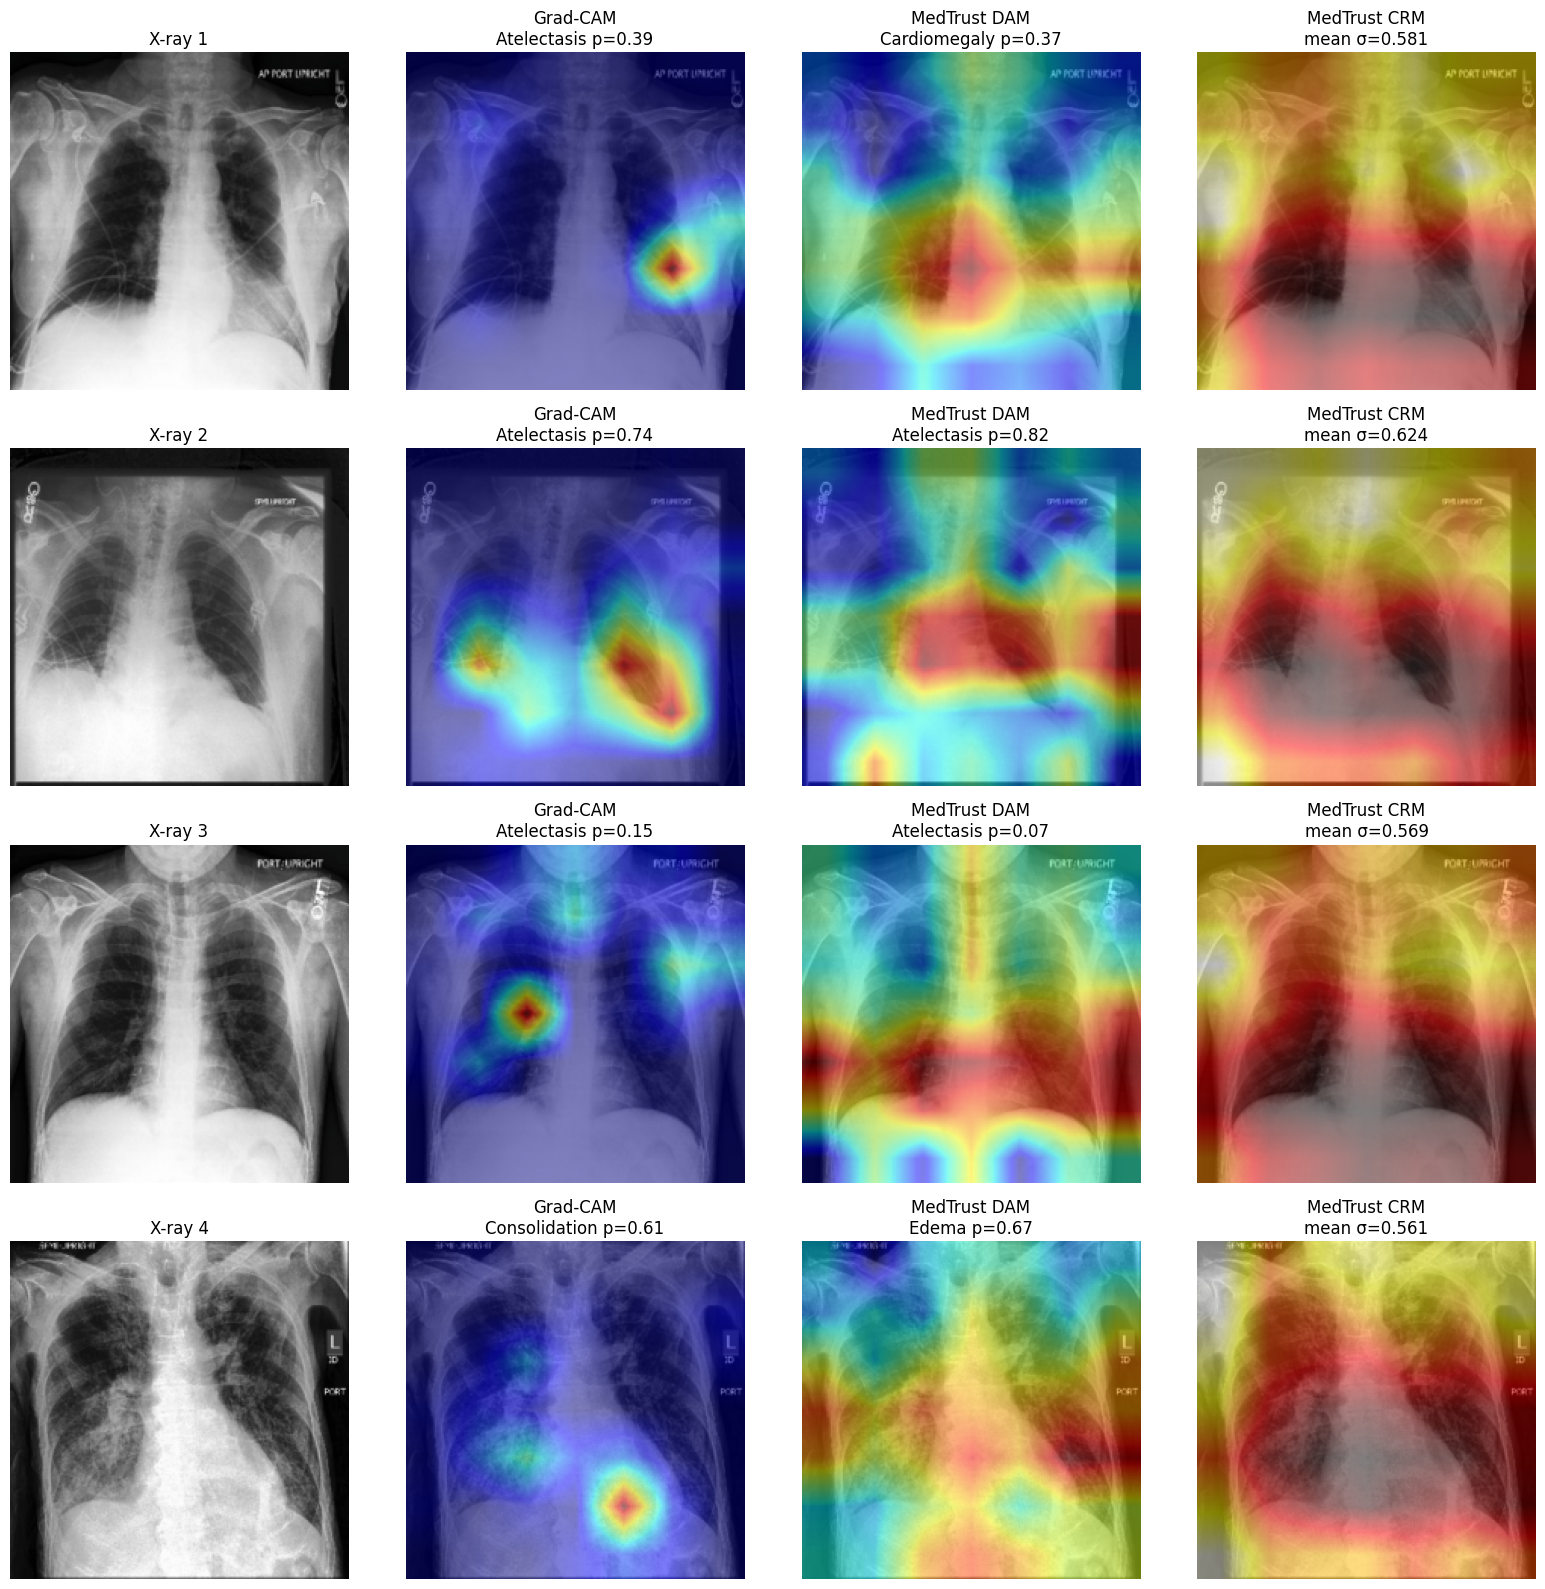

In [ ]:
# --- Figure 7: Qualitative comparison (Grad-CAM vs DAM vs CRM) ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_act)
        target_layer.register_full_backward_hook(self._save_grad)
    def _save_act(self, m, i, o): self.activations = o.detach()
    def _save_grad(self, m, gi, go): self.gradients = go[0].detach()
    def __call__(self, x, class_idx):
        self.model.eval()
        x = x.requires_grad_(True)
        logits = self.model(x)
        score = logits[:, class_idx].sum()
        self.model.zero_grad()
        score.backward()
        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False)
        cam = cam[0,0].cpu().numpy()
        if cam.max() > 0: cam = cam / cam.max()
        return cam

gradcam = GradCAM(m_baseline, m_baseline.layer4)

n_samples = 4
fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4 * n_samples))
m_full.eval()
for i in range(n_samples):
    img, lbl = test_dataset[i * 5]
    img_b = img.unsqueeze(0).to(device)
    with torch.no_grad():
        b_logits = m_baseline(img_b)
        b_probs = torch.sigmoid(b_logits)[0].cpu().numpy()
    top_class = int(np.argmax(b_probs))
    cam = gradcam(img_b.clone(), top_class)
    with torch.no_grad():
        f_logits, dam, crm = m_full(img_b, return_maps=True)
        f_probs = torch.sigmoid(f_logits)[0].cpu().numpy()
    dam_up = F.interpolate(dam, size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False)[0,0].cpu().numpy()
    crm_up = F.interpolate(crm, size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False)[0,0].cpu().numpy()
    img_disp = img.permute(1,2,0).numpy()
    img_disp = np.clip(img_disp * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN), 0, 1)

    axes[i,0].imshow(img_disp); axes[i,0].set_title(f'X-ray {i+1}'); axes[i,0].axis('off')
    axes[i,1].imshow(img_disp); axes[i,1].imshow(cam, cmap='jet', alpha=0.5)
    axes[i,1].set_title(f'Grad-CAM\n{PATHOLOGIES[top_class]} p={b_probs[top_class]:.2f}'); axes[i,1].axis('off')
    axes[i,2].imshow(img_disp); axes[i,2].imshow(dam_up, cmap='jet', alpha=0.5)
    axes[i,2].set_title(f'MedTrust DAM\n{PATHOLOGIES[int(np.argmax(f_probs))]} p={f_probs.max():.2f}'); axes[i,2].axis('off')
    axes[i,3].imshow(img_disp); axes[i,3].imshow(crm_up, cmap='hot', alpha=0.5)
    axes[i,3].set_title(f'MedTrust CRM\nmean σ={crm_up.mean():.3f}'); axes[i,3].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'qualitative_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Final summary

In [ ]:
print("\n" + "=" * 110)
print("FINAL RESULTS (test set: official CheXpert valid.csv, n=234, radiologist-labeled)")
print("=" * 110)
print(f"{'Model':22s} {'AUROC':>8s} {'ECE':>8s} {'F1':>8s} {'Prec':>8s} {'Recall':>8s} {'Spec':>8s} {'Acc':>8s} {'ms':>8s}")
print("-" * 110)
for n in model_names:
    r = all_results[n]
    star = " <-- HERO" if n == 'medtrust_full' else ""
    print(f"{n:22s} {r['macro_auroc']:>8.4f} {r['macro_ece']:>8.4f} "
          f"{r['macro_f1']:>8.4f} {r['macro_precision']:>8.4f} "
          f"{r['macro_recall']:>8.4f} {r['macro_specificity']:>8.4f} "
          f"{r['macro_accuracy']:>8.4f} {r['inference_ms']:>8.1f}{star}")

print(f"\nAll metrics: {METRICS_DIR}")
print(f"All figures: {FIGURES_DIR}")



FINAL RESULTS (test set: official CheXpert valid.csv, n=234, radiologist-labeled)
Model                     AUROC      ECE       F1     Prec   Recall     Spec      Acc       ms
--------------------------------------------------------------------------------------------------------------
resnet50_baseline        0.8682   0.0977   0.6324   0.6568   0.6391   0.8750   0.8040      6.1
resnet50_cal             0.8591   0.1146   0.5849   0.6366   0.5876   0.8748   0.7911      5.7
medtrust_cab_only        0.8775   0.1143   0.6446   0.6328   0.7089   0.8407   0.7990      8.7
medtrust_full            0.8702   0.1136   0.6540   0.6546   0.7023   0.8556   0.8079      8.6 <-- HERO
mc_dropout               0.8676   0.0990   0.6216   0.6445   0.6302   0.8699   0.7980    122.0
deep_ensemble            0.8718   0.1132   0.6391   0.6751   0.6703   0.8662   0.8050     18.3

All metrics: /content/drive/MyDrive/medtrust_results/metrics
All figures: /content/drive/MyDrive/medtrust_results/figures
